In [7]:
# Import necessary libraries
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Locate the CSV whether Jupyter starts in spark or day8.
candidates = [Path("day7/Cancer_Prediction.csv"),
              Path("../day7/Cancer_Prediction.csv")]
data_path = next((path for path in candidates if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError("Open this notebook from the spark or day8 folder to find day7/Cancer_Prediction.csv.")
data = pd.read_csv(data_path)

# Remove the empty trailing CSV column. IDs and diagnosis are not features.
# Diagnosis is kept only for comparison after unsupervised clustering.
data = data.dropna(axis=1, how="all")
df = data.drop(columns=["id", "diagnosis"]).copy()
features = df.columns.tolist()

# K-means uses distances, so standardize all 30 numeric measurements.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
print(f"Loaded {len(df)} samples with {len(features)} features.")


Loaded 569 samples with 30 features.


In [8]:
df.head()


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


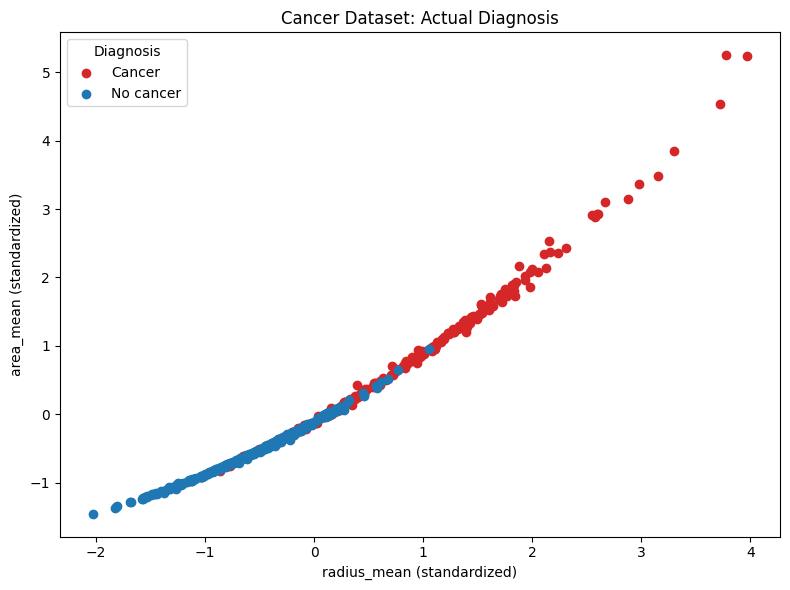

Centroids in standardized feature units:
   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0    -0.482995     -0.239041       -0.500419  -0.478142        -0.311004   
1     0.933624      0.462065        0.967305   0.924243         0.601167   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0         -0.526019       -0.579036            -0.587171      -0.309084   
1          1.016789        1.119270             1.134996       0.597456   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0               -0.149141  ...     -0.517854      -0.251478        -0.532311   
1                0.288288  ...      1.001006       0.486104         1.028953   

   area_worst  smoothness_worst  compactness_worst  concavity_worst  \
0   -0.499358         -0.316078          -0.492241        -0.536843   
1    0.965253          0.610976           0.951497         1.037713   

   concave points_worst  symmetry_worst  fractal_

In [9]:
# Fit two clusters using all measurements, without diagnosis labels.
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(df_scaled)
df["Cluster"] = kmeans.labels_

# Color by the recorded diagnosis, not the arbitrary K-means cluster number.
x_index, y_index = 0, 3
plt.figure(figsize=(8, 6))
for diagnosis, label, color in [("M", "Cancer", "tab:red"),
                                ("B", "No cancer", "tab:blue")]:
    mask = data["diagnosis"].eq(diagnosis).to_numpy()
    plt.scatter(df_scaled[mask, x_index], df_scaled[mask, y_index],
                color=color, label=label, marker="o")
plt.title("Cancer Dataset: Actual Diagnosis")
plt.xlabel(f"{features[x_index]} (standardized)")
plt.ylabel(f"{features[y_index]} (standardized)")
plt.legend(title="Diagnosis")
plt.tight_layout()
plt.show()

print("Centroids in standardized feature units:")
print(pd.DataFrame(kmeans.cluster_centers_, columns=features))
print("\nInertia:", kmeans.inertia_)
print("\nData with cluster assignments:")
print(df.head())


In [10]:
# Include original identifiers and diagnosis for reviewing the results.
results = data.copy()
results["Cluster"] = kmeans.labels_
results.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Cluster
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [11]:
# Cluster numbers are arbitrary; they are not diagnosis predictions.
pd.crosstab(results["Cluster"], results["diagnosis"],
            rownames=["Cluster"], colnames=["Actual diagnosis"])


Actual diagnosis,B,M
Cluster,,
0,339,36
1,18,176
